In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score, balanced_accuracy_score

sys.path.insert(0, str(Path("src").resolve()))
from load_df import load_K9, load_TE_map, build_te_df, sample_negatives, build_full_df
from load_tensors import make_splits
from simple_random_forest import build_feature_matrix

DATA_DIR = Path("test_data")

A4_k9    = load_K9(str(DATA_DIR / "A4_K9.bed"))
A7_k9    = load_K9(str(DATA_DIR / "A7_K9.bed"))
A4_to_A7 = load_TE_map(str(DATA_DIR / "A4_to_A7_map.txt"))
A7_to_A4 = load_TE_map(str(DATA_DIR / "A7_to_A4_map.txt"))

te_df   = build_te_df(A4_k9, A7_k9, A4_to_A7, A7_to_A4)
neg_df  = sample_negatives(te_df, A4_k9, A7_k9, neg_ratio=0.10)
full_df = build_full_df(te_df, neg_df)

# Use same test split to CNN; combine train+val as RF training set
train_df, val_df, test_df = make_splits(full_df)
rf_train_df = pd.concat([train_df, val_df], ignore_index=True)

print(f"RF train: {len(rf_train_df)}  |  Test: {len(test_df)}  |  Total: {len(full_df)}")

RF train: 904  |  Test: 160  |  Total: 1064


In [2]:
"""Dataset summary."""
summary = pd.DataFrame({
    "Count": [
        len(A4_to_A7), len(A7_to_A4),
        len(te_df), len(neg_df), len(full_df),
        len(rf_train_df), len(test_df),
    ]
}, index=[
    "A4 mapped TEs", "A7 mapped TEs",
    "Total TE loci", "Negatives", "Total",
    "RF Train (train+val)", "Test",
])
display(summary)

,Count
A4 mapped TEs (flag=1),497
A7 mapped TEs (flag=1),471
Total TE loci,968
Negatives,96
Total,1064
RF Train (train+val),904
Test,160


In [3]:
"""Train Random Forest and evaluate on test set."""
X_train = build_feature_matrix(rf_train_df)
X_test  = build_feature_matrix(test_df)
y_train = rf_train_df[["label_A4", "label_A7"]].values
y_test  = test_df    [["label_A4", "label_A7"]].values

model = MultiOutputClassifier(RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42),n_jobs=-1)
model.fit(X_train, y_train)

proba = np.column_stack([est.predict_proba(X_test)[:, 1] for est in model.estimators_])
preds = (proba >= 0.5).astype(int)

rf_metrics = {}
for i, strain in enumerate(["A4", "A7"]):
    rf_metrics[f"auROC_{strain}"] = roc_auc_score(y_test[:, i], proba[:, i])
    rf_metrics[f"bAcc_{strain}"]  = balanced_accuracy_score(y_test[:, i], preds[:, i])

# CNN test results from result_visualization.ipynb
cnn_metrics = {"auROC_A4": 0.715, "auROC_A7": 0.708, "bAcc_A4": 0.590, "bAcc_A7": 0.596}

comparison = pd.DataFrame({
    "auROC A4": [rf_metrics["auROC_A4"],  cnn_metrics["auROC_A4"]],
    "auROC A7": [rf_metrics["auROC_A7"],  cnn_metrics["auROC_A7"]],
    "Mean auROC": [
        np.mean([rf_metrics["auROC_A4"],  rf_metrics["auROC_A7"]]),
        np.mean([cnn_metrics["auROC_A4"], cnn_metrics["auROC_A7"]]),
    ],
    "bAcc A4": [rf_metrics["bAcc_A4"],  cnn_metrics["bAcc_A4"]],
    "bAcc A7": [rf_metrics["bAcc_A7"],  cnn_metrics["bAcc_A7"]],
}, index=["Random Forest", "CNN"])

display(comparison.round(3))

,auROC A4,auROC A7,Mean auROC,bAcc A4,bAcc A7
Random Forest,0.795,0.728,0.761,0.68,0.661
CNN,0.715,0.708,0.712,0.59,0.596


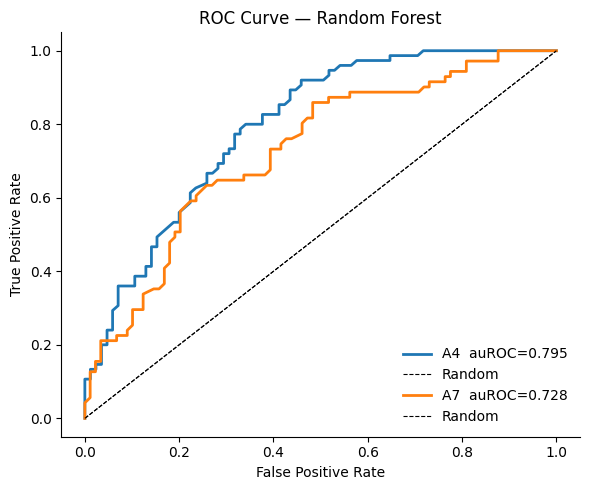

In [4]:
"""ROC curves for A4 and A7 on the test set."""
fig, ax = plt.subplots(figsize=(6, 5))

for i, strain, color in [(0, "A4", "tab:blue"), (1, "A7", "tab:orange")]:
    fpr, tpr, _ = roc_curve(y_test[:, i], proba[:, i])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{strain}  auROC={auc(fpr, tpr):.3f}")
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve — Random Forest")
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

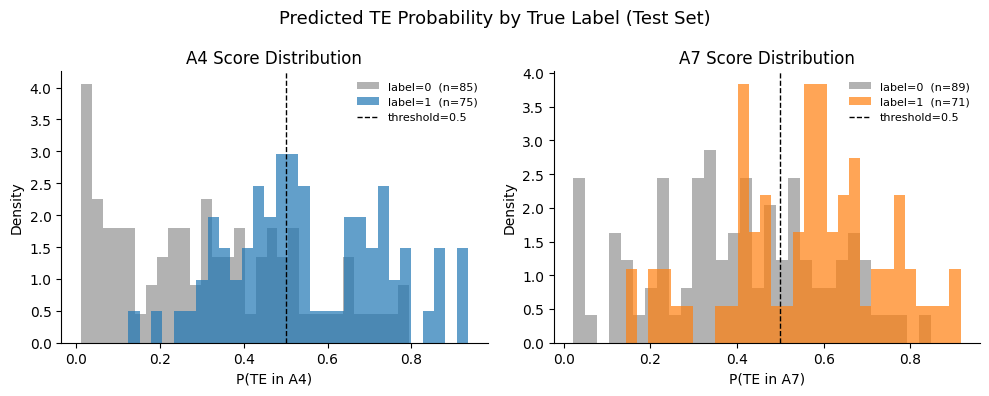

In [5]:
"""Score distributions: predicted probability of TE by true label."""
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, i, strain, color in [
    (axes[0], 0, "A4", "tab:blue"),
    (axes[1], 1, "A7", "tab:orange"),
]:
    for lv, c, alpha in [(0, "tab:gray", 0.6), (1, color, 0.7)]:
        mask = y_test[:, i] == lv
        ax.hist(proba[mask, i], bins=30, alpha=alpha, color=c,
                label=f"label={lv}  (n={mask.sum()})", density=True)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1.0, label="threshold=0.5")
    ax.set_xlabel(f"P(TE in {strain})")
    ax.set_ylabel("Density")
    ax.set_title(f"{strain} Score Distribution")
    ax.legend(fontsize=8, frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Predicted TE Probability by True Label (Test Set)", fontsize=13)
plt.tight_layout()
plt.show()

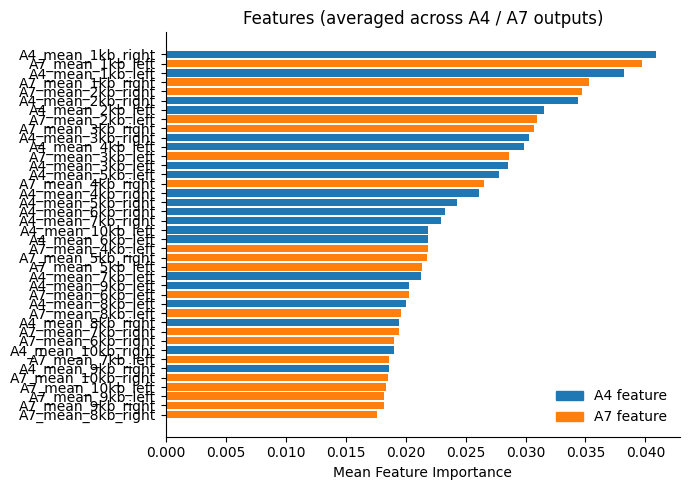

In [6]:
"""Feature importance: features averaged across A4 and A7 RF heads."""
importances  = np.mean([est.feature_importances_ for est in model.estimators_], axis=0)
feature_names = X_train.columns.tolist()
top_idx = np.argsort(importances)[::-1][:40]

top_names  = [feature_names[i] for i in top_idx]
top_values = [importances[i]   for i in top_idx]

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["tab:blue" if "A4" in n else "tab:orange" for n in top_names]
ax.barh(top_names[::-1], top_values[::-1], color=colors[::-1])
ax.set_xlabel("Mean Feature Importance")
ax.set_title("Features (averaged across A4 / A7 outputs)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="tab:blue",   label="A4 feature"),
    Patch(color="tab:orange", label="A7 feature"),
], frameon=False)

plt.tight_layout()
plt.show()